In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans

## 請安裝
> pip install opencv-python

# Problem : K-Means Clustering
**K-Means Clustering** is an unsupervised learning algorithm for data grouping. In image segmen- tation, it can be applied to partition image pixels into different groups based on the associated pixel values or features. In this problem, you will learn how to segment the provided image by using K-means clustering.
學習利用K-Means分群演算法，隊提供的影像進行分割(segmentatioin)

In [3]:
img = cv2.imread('data/bird.jpg') #從資料夾讀取圖片檔案
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #顏色轉換，把OpenCV的BGR轉成RGB，(原始圖片,轉換方式)
# 若直接使用img，會出現顏色異常，因為Matplotlib使用RGB，OpenCV使用BGR，格式不同

[129 175 100]


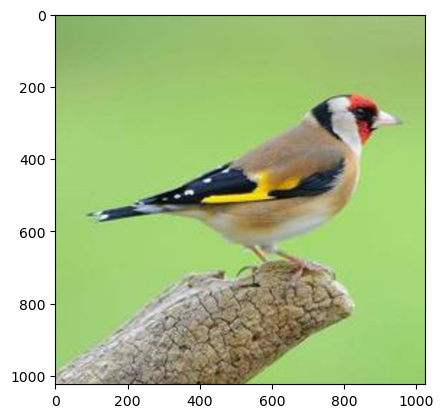

In [5]:
print(img[0,0])
plt.imshow(img)
plt.show()

## 1-1. cluster with only RGB values

In [6]:
def km_clust(array, n_clusters): # 定義K-Means函數，array:要分群的資料，n_clusters:要分幾群(K值)
    # Define the k-means clustering problem
    k_m = KMeans(n_clusters = n_clusters) # 建立K-Means模型，等同k_m = KMeans(n_clusters=2)
    # Solve the k-means clustering problem
    k_m.fit(array) # 訓練模型，動作是隨機選K個中心點，計算每個點到中心距離，分配群組，更新中心點，重複直到收斂
    # Get the coordinates of the clusters centres
    center = k_m.cluster_centers_ # 取得群中心
    # Get the label of each point
    label = k_m.labels_ # 取得每個點的群組標籤
    return(label, center) # 回傳結果

In [14]:
h, w, c = img.shape # 取得圖片尺寸，h:高，w:寬，c:顏色通道(RGB)
print(img.shape)

(1024, 1024, 3)


In [15]:
# 將圖片轉成K-Means可處理格式
Z = img.reshape((-1,3)) # -1的意思是Python自動計算列數，1024*1024=1048576，因此變成(1048576,3)
K = 2
label, center = km_clust(Z,K) # 執行K-Means，得到label及center，K=2，表示兩個群中心，每個中心有RGB三個值
center = np.uint8(center[:,:3]) # 將中心值轉成8位元顏色，因為圖片顏色需要整數，0~255整數
center

array([[107,  95,  71],
       [163, 197, 120]], dtype=uint8)

## 1-2. cluster with RGB values and the location

做K-Means影像分割，且不只用RGB顏色，還額外加入位置資訊(h,w)，也就是每個像素有5個特徵。
但分群效果不好，因為位置特徵值太大，導致K-Means會太重視位置，而不是顏色。
另沒有做標準化，因位置尺度不同，K-Means是距離演算法，尺度會嚴重影響結果。
另KMeans沒設定random_state/n_init，不同執行結果可能不穩定

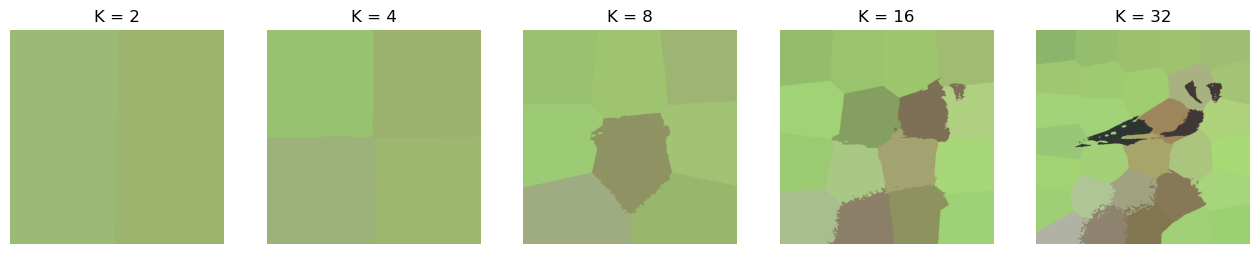

In [17]:
h, w, c = img.shape

#Added location feature
Z = np.zeros((h, w, c+2)) # 建立新矩陣，比原圖多2個欄位，用來放位置資訊
for h in range(len(img)): # 逐一把每個像素加上座標
    for w in range(len(img[h])):
        Z[h][w] = np.append(img[h][w], [[h], [w]])
Z = Z.reshape(-1, 5) # 把圖片從hxwx5攤平成像素總數x5，方便丟進K-Means

Ks = [2,4,8,16,32]
plt.figure(figsize=(16,12))

for i, K in enumerate(Ks): # 依序用不同K值做分群
    label, center = km_clust(Z, K)

    # Now convert back into uint8, and make original image
    center = np.uint8(center[:, :3]) # 只取中心點的前三個欄位，不取位置資訊
    res = center[label.flatten()] # 把每個像素改成所屬群組的代表色
    res = res.reshape((img.shape)) # 再還原成原圖大小

    plt.subplot(1, 5, i+1)
    plt.axis('off')
    plt.title("K = {}".format(K))
    plt.imshow(res)
    
plt.show()

## 1-3. explain the differences between the two methods under the same K.
![](images/7.4_result.PNG)

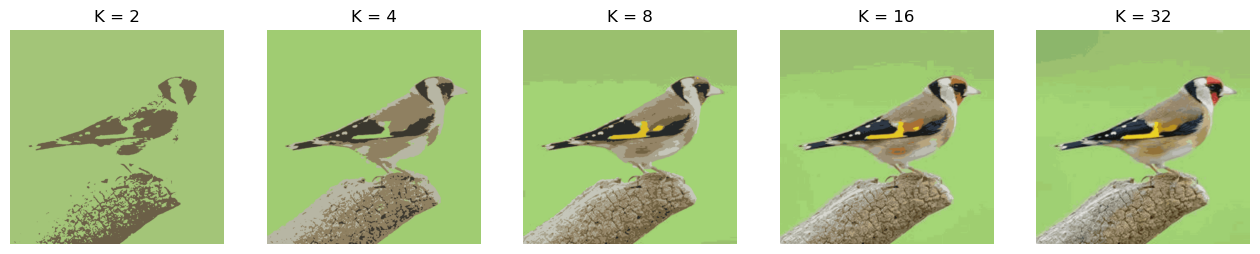

In [19]:
h, w, c = img.shape

Z = img.reshape((-1,3))
Ka = [2,4,8,16,32]
plt.figure(figsize=(16,12))
      
for i, K in enumerate(Ka):
    label, center = km_clust(Z, K)

    # Now convert back into uint8, and make original image
    center = np.uint8(center[:, :3])
    res = center[label.flatten()]
    res = res.reshape((img.shape))

    plt.subplot(1, 5, i+1)
    plt.axis('off')
    plt.title("K = {}".format(K))
    plt.imshow(res)
    
plt.show()

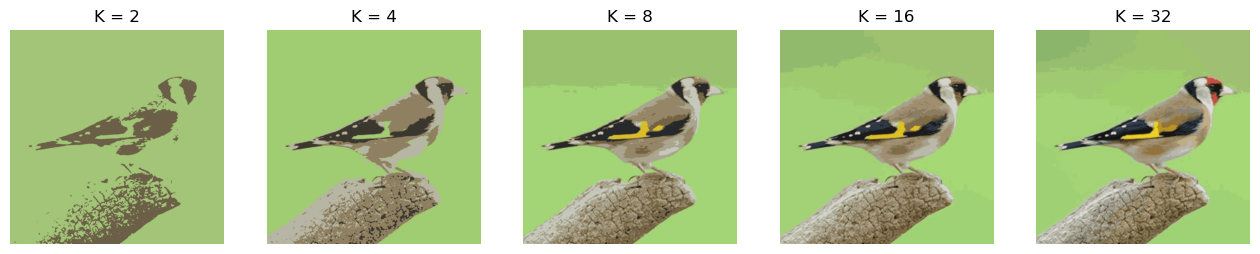

In [21]:
# 調整位置權重
h, w, c = img.shape

rgb = img.reshape(-1,3)

yy, xx = np.indices((h,w))
position = np.stack([yy.ravel(), xx.ravel()], axis=1)
position = position / np.array([h,w])
position_weight = 30

Z = np.hstack([rgb, position * position_weight])

Ks = [2,4,8,16,32]
plt.figure(figsize=(16,12))

for i, K in enumerate(Ks): # 依序用不同K值做分群
    label, center = km_clust(Z, K)

    # Now convert back into uint8, and make original image
    center = np.uint8(center[:, :3]) # 只取中心點的前三個欄位，不取位置資訊
    res = center[label.flatten()] # 把每個像素改成所屬群組的代表色
    res = res.reshape((img.shape)) # 再還原成原圖大小

    plt.subplot(1, 5, i+1)
    plt.axis('off')
    plt.title("K = {}".format(K))
    plt.imshow(res)
    
plt.show()